# Test — Profit Margin theo Category

Dựng lại biểu đồ **biên lợi nhuận theo Category** cho kỳ **YTD: 01/01/2026 → 05/06/2026** (lũy kế từ đầu năm tới cutoff, không phải một tháng riêng lẻ): mỗi cột kèm nhãn margin % + doanh thu, và đường target 14%.
Số liệu tính trực tiếp từ `SampleSuperstore.csv` qua cùng pipeline với `superstore_dashboard.ipynb` (dịch +9 năm, cutoff 05/06/2026).

In [1]:
import os, sys
import pandas as pd
import matplotlib.pyplot as plt

# Tìm thư mục gốc dự án (chứa src/) — chạy được dù mở từ root hay từ notebook/
cwd = os.getcwd()
ROOT = cwd if os.path.isdir(os.path.join(cwd, 'src')) else os.path.dirname(cwd)
sys.path.append(os.path.join(ROOT, 'src'))
from utils import load_and_shift

CSV_PATH    = os.path.join(ROOT, 'notebook', 'SampleSuperstore.csv')
SHIFT_YEARS = 9                          # 2014-2017 -> 2023-2026
CUTOFF      = pd.Timestamp('2026-06-05')  # mốc phân tích

# Đọc + dịch dữ liệu, lọc YTD 2026
df = load_and_shift(CSV_PATH, shift_years=SHIFT_YEARS)
df_curr = df[(df['Order Date'] >= pd.Timestamp(f'{CUTOFF.year}-01-01')) & (df['Order Date'] <= CUTOFF)]

# Biên lợi nhuận theo Category
cat = (df_curr.groupby('Category')
              .agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum')))
cat['margin'] = cat['Profit'] / cat['Sales'] * 100

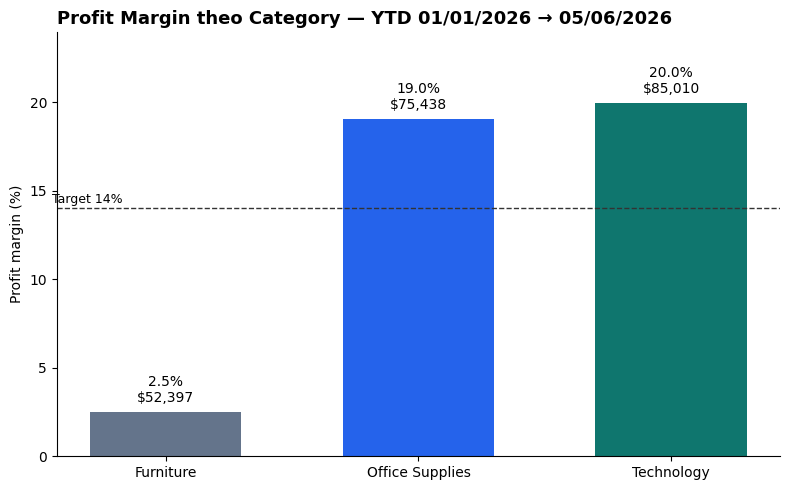

In [2]:
TARGET = 14.0
colors = {'Furniture': '#64748B', 'Office Supplies': '#2563EB', 'Technology': '#0F766E'}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(cat.index, cat['margin'], color=[colors[c] for c in cat.index], width=0.6)

# Nhãn margin % + doanh thu trên mỗi cột
for c, b in zip(cat.index, bars):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.4,
            f"{cat.loc[c, 'margin']:.1f}%\n${cat.loc[c, 'Sales']:,.0f}",
            ha='center', va='bottom', fontsize=10)

# Đường target 14%
ax.axhline(TARGET, ls='--', color='#333', lw=1)
ax.text(-0.45, TARGET + 0.3, f'Target {TARGET:.0f}%', fontsize=9)

# Tiêu đề ghi rõ kỳ dữ liệu: lũy kế từ đầu năm (YTD) tới cutoff
ax.set_title(f'Profit Margin theo Category — YTD 01/01/{CUTOFF.year} → {CUTOFF:%d/%m/%Y}',
             fontsize=13, fontweight='bold', loc='left')
ax.set_ylabel('Profit margin (%)')
ax.set_ylim(0, cat['margin'].max() + 4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Region Performance — Sales và YoY

Biểu đồ kết hợp: **cột** = doanh thu YTD 2026 theo khu vực (trục trái), **đường cam** = tăng trưởng so với cùng kỳ 2025 (trục phải). Số liệu tính trực tiếp từ dữ liệu, cùng pipeline (dịch +9 năm, cutoff 05/06/2026).

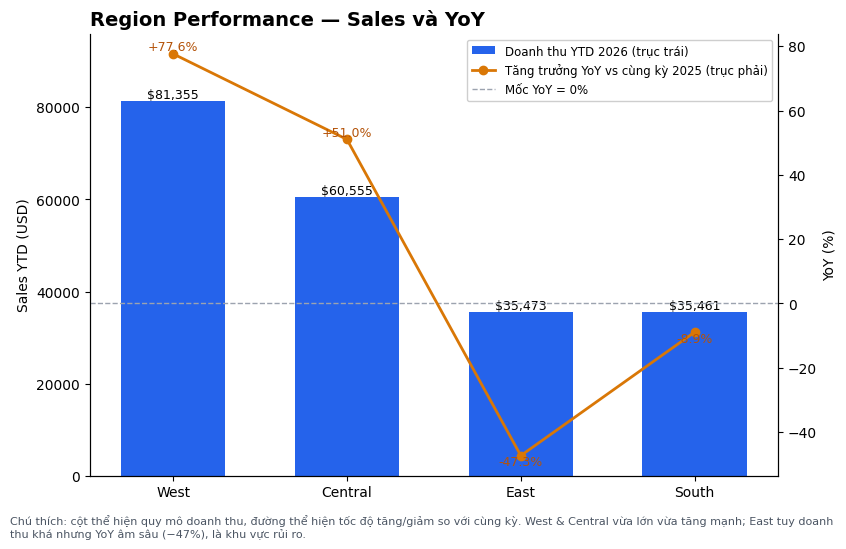

In [3]:
# --- Region Performance: Sales YTD (cột) + YoY (đường) ---
# YoY = doanh thu YTD 2026 so với CÙNG KỲ 2025 (cùng khoảng 01/01 → cutoff)
YR_START    = pd.Timestamp(f'{CUTOFF.year}-01-01')
PREV_START  = pd.Timestamp(f'{CUTOFF.year - 1}-01-01')
df_prev_ytd = df[(df['Order Date'] >= PREV_START) & (df['Order Date'] <= PREV_START + (CUTOFF - YR_START))]

reg = df_curr.groupby('Region')['Sales'].sum().rename('Sales').to_frame()
reg['prev'] = df_prev_ytd.groupby('Region')['Sales'].sum()
reg = reg.fillna(0)
reg['YoY'] = (reg['Sales'] - reg['prev']) / reg['prev'] * 100
reg = reg.sort_values('Sales', ascending=False)

fig, ax1 = plt.subplots(figsize=(8.5, 5.2))

# Cột doanh thu (trục trái)
bars = ax1.bar(reg.index, reg['Sales'], color='#2563EB', width=0.6, zorder=2,
               label='Doanh thu YTD 2026 (trục trái)')
ax1.set_ylabel('Sales YTD (USD)')
ax1.set_ylim(0, reg['Sales'].max() * 1.18)
for b, v in zip(bars, reg['Sales']):
    ax1.text(b.get_x() + b.get_width() / 2, b.get_height(), f'${v:,.0f}',
             ha='center', va='bottom', fontsize=9)

# Đường YoY (trục phải)
ax2 = ax1.twinx()
line, = ax2.plot(reg.index, reg['YoY'], color='#d97706', marker='o', lw=2, zorder=3,
                 label='Tăng trưởng YoY vs cùng kỳ 2025 (trục phải)')
zero = ax2.axhline(0, color='#9ca3af', lw=1, ls='--', zorder=1, label='Mốc YoY = 0%')
ax2.set_ylabel('YoY (%)')
for x, v in enumerate(reg['YoY']):
    ax2.text(x, v, f'{v:+.1f}%', ha='center', va='bottom' if v >= 0 else 'top',
             fontsize=9, color='#b45309')

# Chú thích (legend) gộp từ cả hai trục
handles = [bars, line, zero]
labels  = [h.get_label() for h in handles]
ax1.legend(handles, labels, loc='upper right', fontsize=8.5, framealpha=0.95)

ax1.set_title('Region Performance — Sales và YoY', fontsize=14, fontweight='bold', loc='left')
ax1.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)

# Ghi chú diễn giải dưới biểu đồ
fig.text(0.01, -0.04,
         'Chú thích: cột thể hiện quy mô doanh thu, đường thể hiện tốc độ tăng/giảm so với cùng kỳ. '
         'West & Central vừa lớn vừa tăng mạnh; East tuy doanh thu khá nhưng YoY âm sâu (−47%), là khu vực rủi ro.',
         fontsize=8, color='#4b5563', wrap=True)

plt.tight_layout()
plt.show()

## Sub-category Profitability — Nhóm kéo lên / kéo xuống

Từ **top 10 sub-category theo doanh thu**, lấy **4 nhóm biên lợi nhuận cao nhất** (kéo lên, màu xanh) và **các nhóm đang lỗ** (kéo xuống, màu đỏ). Nhãn mỗi cột: `margin% | profit`. Số tính từ `df_curr` cho kỳ **YTD: 01/01/2026 → 05/06/2026** (lũy kế từ đầu năm tới cutoff).

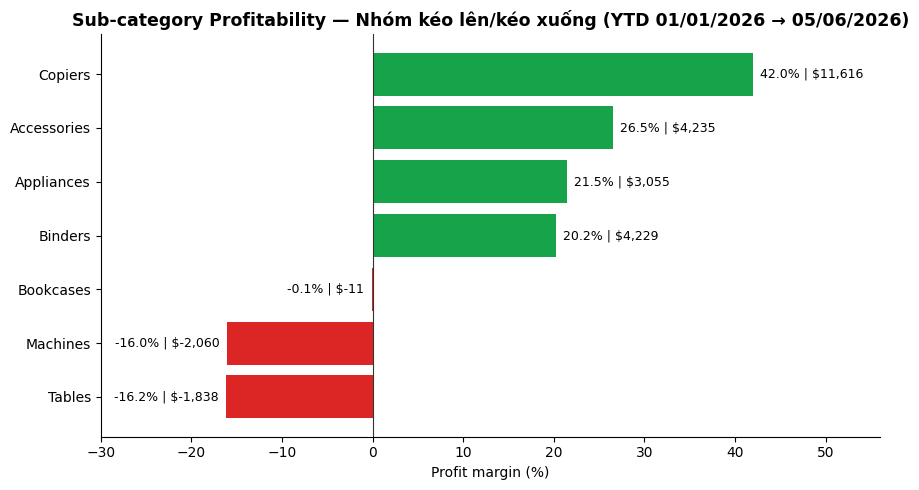

In [4]:
# Top 10 sub-category theo doanh thu (giống dashboard)
sc = (df_curr.groupby('Sub-Category')
             .agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum')))
sc['margin'] = sc['Profit'] / sc['Sales'] * 100
top10 = sc.sort_values('Sales', ascending=False).head(10)

# Nhóm kéo lên = 4 biên cao nhất; nhóm kéo xuống = các sub-category đang lỗ
up   = top10.sort_values('margin', ascending=False).head(4)
down = top10[top10['margin'] < 0]
movers = pd.concat([up, down]).sort_values('margin')   # tăng dần -> cao nhất nằm trên cùng

colors = ['#16A34A' if m >= 0 else '#DC2626' for m in movers['margin']]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(movers.index, movers['margin'], color=colors)

for idx, b in zip(movers.index, bars):
    m, p = movers.loc[idx, 'margin'], movers.loc[idx, 'Profit']
    off = 0.8 if m >= 0 else -0.8
    ax.text(b.get_width() + off, b.get_y() + b.get_height() / 2,
            f'{m:.1f}% | ${p:,.0f}', va='center',
            ha='left' if m >= 0 else 'right', fontsize=9)

ax.axvline(0, color='#333', lw=0.8)
# Tiêu đề ghi rõ kỳ dữ liệu: lũy kế từ đầu năm (YTD) tới cutoff
ax.set_title(f'Sub-category Profitability — Nhóm kéo lên/kéo xuống (YTD 01/01/{CUTOFF.year} → {CUTOFF:%d/%m/%Y})',
             fontsize=12.5, fontweight='bold')
ax.set_xlabel('Profit margin (%)')
ax.set_xlim(-30, 56)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## EDA — Lợi nhuận trung bình theo mức chiết khấu

Phát hiện cốt lõi của EDA: chiết khấu cao kéo lợi nhuận trung bình về âm. Đây là động lực cho mô hình profit-driver (Phụ lục B).

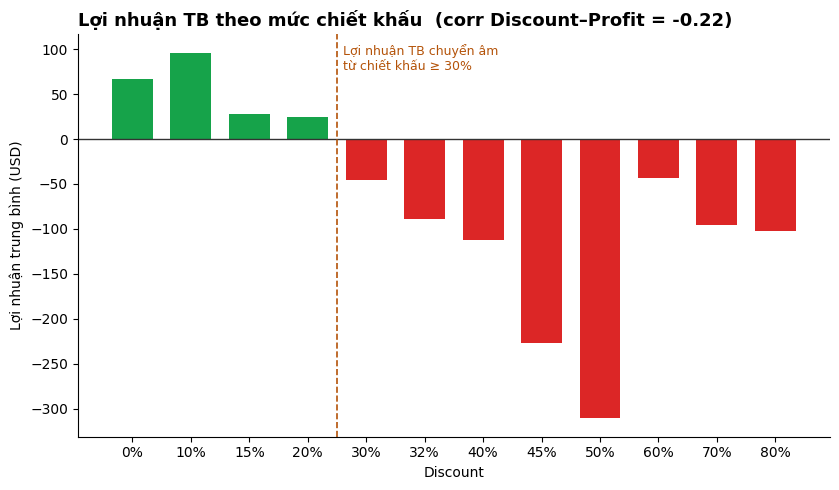

In [5]:
# EDA: Lợi nhuận TB theo mức Discount (toàn bộ dữ liệu) + ngưỡng chuyển âm
by_disc = df.groupby('Discount')['Profit'].mean()
colors = ['#dc2626' if v < 0 else '#16a34a' for v in by_disc.values]

fig, ax = plt.subplots(figsize=(8.5, 5))
bars = ax.bar([f'{d*100:.0f}%' for d in by_disc.index], by_disc.values, color=colors, width=0.7)
ax.axhline(0, color='#333', lw=1)

# Ngưỡng chiết khấu mà lợi nhuận TB bắt đầu âm
neg = by_disc[by_disc < 0]
if len(neg):
    thr = neg.index.min()
    ax.axvline(list(by_disc.index).index(thr) - 0.5, color='#b45309', ls='--', lw=1.2)
    ax.text(list(by_disc.index).index(thr) - 0.4, by_disc.max() * 0.8,
            f'Lợi nhuận TB chuyển âm\ntừ chiết khấu ≥ {thr*100:.0f}%',
            fontsize=9, color='#b45309')

corr = df['Discount'].corr(df['Profit'])
ax.set_title(f'Lợi nhuận TB theo mức chiết khấu  (corr Discount–Profit = {corr:.2f})',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Discount'); ax.set_ylabel('Lợi nhuận trung bình (USD)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

## EDA — Tính ổn định mùa vụ qua các năm

Kiểm chứng giả định của pace_weight: trọng số doanh thu từng tháng có ổn định giữa các năm không. Các đường gần trùng nhau ⇒ mùa vụ ổn định ⇒ dùng trung bình nhiều năm là hợp lý.

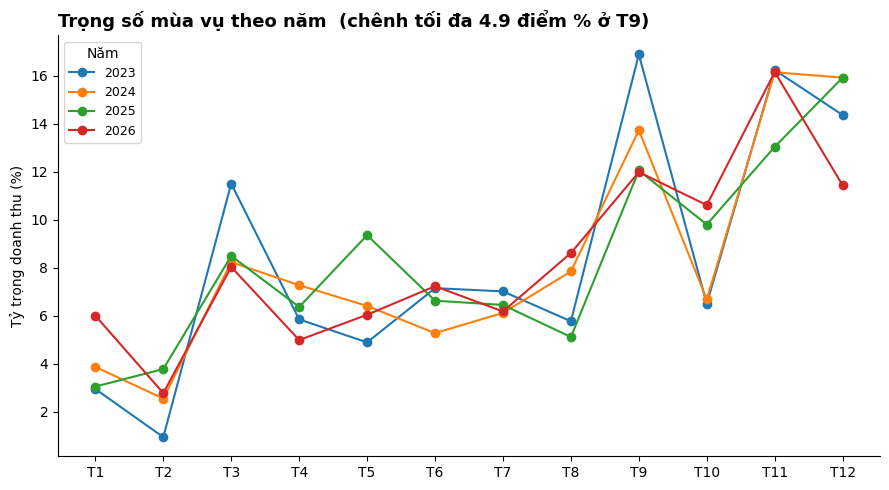

In [6]:
# EDA: Trọng số doanh thu từng tháng theo từng năm (kiểm chứng mùa vụ)
dy = df.copy()
dy['Y'] = dy['Order Date'].dt.year
dy['M'] = dy['Order Date'].dt.month
full_years = [int(y) for y in sorted(dy['Y'].unique())
              if dy[dy['Y'] == y]['M'].nunique() == 12]

fig, ax = plt.subplots(figsize=(9, 5))
wmat = {}
for y in full_years:
    s = dy[dy['Y'] == y].groupby('M')['Sales'].sum().reindex(range(1, 13), fill_value=0)
    w = s / s.sum() * 100
    wmat[y] = w.values
    ax.plot(range(1, 13), w.values, marker='o', label=str(y))

import pandas as _pd
spread = (_pd.DataFrame(wmat).max(axis=1) - _pd.DataFrame(wmat).min(axis=1))
ax.set_xticks(range(1, 13)); ax.set_xticklabels([f'T{m}' for m in range(1, 13)])
ax.set_title(f'Trọng số mùa vụ theo năm  (chênh tối đa {spread.max():.1f} điểm % ở T{spread.values.argmax()+1})',
             fontsize=13, fontweight='bold', loc='left')
ax.set_ylabel('Tỷ trọng doanh thu (%)')
ax.legend(title='Năm', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()